In [1]:
import pandas as pd

In [2]:
import warnings 
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('spam.csv',encoding='latin-1')

In [4]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df = df.drop(columns = ['Unnamed: 2','Unnamed: 3','Unnamed: 4'])

In [6]:
df = df.rename(columns={'v1':'output','v2':'email'})

In [7]:
df['output'] = df['output'].replace(to_replace=['ham','spam'],value=[0,1])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   output  5572 non-null   object
 1   email   5572 non-null   str   
dtypes: object(1), str(1)
memory usage: 87.2+ KB


In [9]:
df.duplicated().sum()

np.int64(403)

In [10]:
df = df.drop_duplicates()

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='output', ylabel='count'>

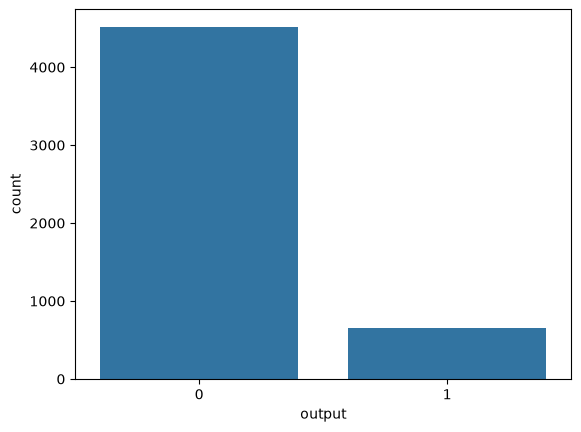

In [12]:
sns.countplot(x= df['output'])

In [13]:
df['email'] = df['email'].apply(lambda x : x.lower())

NOT GONNA DO ANY MORE PREPROCESSING FOR NOW BECAUSE I DON'T WANT VIRTUES OF A SPAM EMAIL TO BE LOST

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report

In [16]:
X = df['email']
y = df['output']

In [17]:
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=42)

In [18]:
bow_vectorizer = CountVectorizer(encoding='latin-1')

In [19]:
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)  